In [134]:
# Imports
%matplotlib inline
%config InlineBackend.figure_format='svg'
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 11})
import vMCS_thermoSim as TS

In [135]:
# import rawdata and settings of the run

# Past data to fit
#path = r"C:\Users\joho1\Documents\Research with Matt\Data-and-Papers\PastData\100_10_400_ss_p375in_900gSinks_4V_340uTorr_January 16, 2026  1-43 PM.csv"

# Trying data taken in vaccuum. April 2026
#path =  r"C:\Users\joho1\Documents\Research with Matt\Data-and-Papers\2026Data\100_60_400_ss_AlRod_10cm_900gSinks_3V_roughvacuum_April 24, 2026  1-56 PM.csv"
path = r"C:\Users\joho1\Documents\Research with Matt\Data-and-Papers\2026Data\100_20_400_ss_AlRod_10cm_900gSinks_3V_roughvacuum_April 24, 2026  1-23 PM.csv"


# For Jerome's data: 1/30/26
with open(path, 'r', encoding='utf-8-sig') as f:
    rawData = np.loadtxt(f,delimiter=",", dtype=float)


#rawData = np.loadtxt(path,delimiter=",", dtype=float)
path = path.split('\\')[-1].split("_")
lagTime = float(path[0])
heatPulse = float(path[1])
dataTime = float(path[2])
print("lagTime: ",lagTime,'s')
print("heatPulse: ",heatPulse,'s')
print("dataTime: ",dataTime,'s')

#ss_small = rawData
#ss_large = rawData

lagTime:  100.0 s
heatPulse:  20.0 s
dataTime:  400.0 s


12/11/2023

If Yash found good agreement between the Q from $I^2 R$ and from $mc\Delta T$ but was using the wrong $T_0$ then that implie that the $T$ we measure is off by a factor of 3068/3518, or $0.87$, or $1.15$.

2/27/2024

We are now working with a new setup.  This has different thermometers with T0=3068K and larger Al sinks at 289.9 g and 294.2 g each.


In [ ]:
# variable setup
"""
Raw Data costants and variables
"""

# resistors and other value yet to be set
resistors=[
    0, # Rf
    0, # R1
    0, # R2
]

defGain = True # True sets gain to the default value below, False will set it to ideal calculated value based on resistor values above

# defGainVal = 18.5
# Changed from 18.5 (Jamie 2021) to 20 due to measurements July 20 2024
defGainVal = 20

# Be careful to use the correct T0 for the different setups.
# Original BGT copper rod: T0 = 3440 K (listed in paper)
# Large copper arch (2016 construction): T0 = 3068 K
# Aluminum arch (2018 consctruction): T0 = 3518 K. 
# 20 cm straight rod, Yash design (summer 2023): T0=3518 K
# 20 cm straight rod, Yash design.  Smaller thermometers: T0=3068 K
T_0 = 3068

#T_air = 22.8 #dgree C
T_air = 23 #dgree C

scale = 1 # scaling factor

"""
Experiment Constants
"""
# duration of the graph staring at t0 = 0  to tf = t0 + dur
dur = dataTime# s

# thermal conductivity (should be same as k_al for aluminum rod) (4.01 and 3.45 for copper)
kappa = 2.37 # W cm^-1 K^-1
k_al = 2.37 # W cm^-1 K^-1
# volumetric heat capacity 
s = 2.422 # J cm^-3 K^-1
s_al = 2.422# J cm^-3 K^-1
c_al = 0.904 # J/(g K)
'''
    Aluminum rod properties
'''
# thermal conductivity 
#k_al = 2.37 # W cm^-1 K^-1
# volumetric heat capacity 
#s_al =2.422 # J m^-2 K^-1

# delta x
dx = 0.05  # cm
# delta t
dt = 0.001 # sec
# heater length
heaterLen = 1
# heat pulse duration
att = heatPulse #sec
# energy input set using raw data later
 # J

"""
ROD Facts
"""
# Left Al sink
# 5.39 cm long
# M1= 56.218 # g mass
# Larger sinks
# M1 = 289.9 # g mass
M1 = 900

# Right Al sink
# 5.45 cm long
# M2 = 56.444 #g mass
# Larger sinks
#M2 = 294.2 # g mass
# Only one mass
M2 = 900


sinkLen = 5.4
rodInSink = 1
radiusOfHeatSink_L = 1.1
radiusOfHeatSink_R = radiusOfHeatSink_L

"""
ROD Conditions
"""


# length of rod
rodLen = 14.5 # cm  22cm for floating rod, 14.5 works best for the aluminum rod
# radius of the cross section area
a = 0.5*(1/8)*2.54 # cm   # 1/8" diameter rod
#a = 0.5*(2/8)*2.54 # cm   # 3/8" diameter rod
# cross section area
A = np.pi * a**2 # cm^2

# inital temperature of rod
#ic =0
ic =T_air

# boundary conditions
bcT = np.zeros((2,1))
bcS = np.zeros((2,1))

# Left end boundary conditions
# initial temperature 
bcT[0] = ic
# diffusion state
# 1) heat sunk
# 2) free
bcS[0] = 0

# Right end boundary conditions
# initial temperature 
bcT[1] = ic
# diffusion state
# 1) heat sunk
# 2) free
bcS[1] = 0

#Both were previously 3 

# position of heater
atX = rodLen/2


# time domain (for plotting and analytical method )
t = np.arange(0,dataTime,dt)

h = 0.001175898656696838


In [137]:
mass = ((5.45)*np.pi*(1.11**2))*(2.71)
print(mass)

length_al = 56.444/(1.11**2*np.pi*2.71)
print(length_al)

57.16913529821329
5.380872010663665


### Don't forget to change the $R_{eq}$ in calculatedQ in vmCS_thermoSim when switching rods

In [138]:
# numerical model


Q = TS.calculateQ(rawData,0.01,att,lagTime)
heatlossBool = False

print("Heat Pulse: ",Q,'J')



Heat Pulse:  13.390266634353452 J


In [139]:
# calculate the expected temperature changes

# For a single copper rod that is floating.
T_float = Q/(s*(rodLen)*A)

print(T_float)

#For the experiment plus the sinks
#Tend = Q/(s_al*(sinkLen*np.pi*radiusOfHeatSink_L**2 + sinkLen*np.pi*radiusOfHeatSink_R**2) + s*rodLen*A) # Using volume
Tend = Q/(c_al*(M1+M2) + s*rodLen*A) # using mass


print(Tend,Q)

4.815814426030565
0.008214985893456784 13.390266634353452


In [140]:
# Trying to integrate my solve_ivp code here
# MCS 12/1/2023

# There is a units difference between my code and Yash's code.
# I don't know if it makes a difference but I iwll convert to SI units.

# 12/3/2023
# I can't see whythe units should make a difference, because all the units of distance should cancel.
# I am going to try the whole thing in cm instead of m.

# Now the PDE constants:
beta = kappa/(s*dx**2) # converted to SI units.
gamma = 1/s

h = 0.0003 # Heat loss.  What are the units now? 
# Here are some values for h that have worked well. 1/5/2026
#  0.0004 or 0.0005 for vacuum.
#  5*0.0005*.7 was a value that I tested out for air and seemed to work ok.

delta = 2*h/(s*a)
#delta = 0  # no heat loss

# This is the heater.  Translated from Yash's code.
N = int(rodLen/dx) +1
x = dx*np.arange(0,N) -rodLen/2 #positions along the rod, centered about zero.
num_seg = sum(abs(x)<= heaterLen/2) # number of segments that have the heater
x_h = np.zeros(len(x))
#I want to define a vector that is zeros and ones, one for the location of the heater.
# Heater is in the center of the rod.
x_h[int((N-num_seg)/2):int((N+num_seg)/2)]=1
vol_h = np.pi*num_seg*dx*a**2 

#My model needs the power per volume.
P = Q/att    # Power in Watts.  att is the pulse time.
# The following is a vector with the power/volume in each heater segment.
x_h = x_h*(P/vol_h)


In [141]:
print(h)

0.0003


In [142]:
# This is the PDE for my solve-ivp solutions
# 12/1/2023
# 12/3/2023 adjusted the parameters to be in cm instead of m.  Still works.
# This confuses me some, because the energy is in J (kg m^2/s^2), so how does that work out?
# Oh, maybe the J in s cancels the J in Q.

# Initial conditions
y_0 = np.zeros(N)
#y_0[20] =  50

#I need some times for integration
t_start = 0
t_stop = dataTime 
time = np.linspace(t_start, t_stop, 10000)
tspan = [t_start, t_stop]

#bcS = np.zeros((2,1))
bcS[0] = 0
bcS[1] = 0
sol = solve_ivp(TS.numMCS, tspan, y_0, args= (beta, gamma, delta, x_h, att, bcS))
#bcS[0] = 1
#bcS[1] = 1
#sol1 = solve_ivp(TS.numMCS, tspan, y_0, args= (beta, gamma, delta, x_h, att, bcS))

In [143]:
sol1=sol

c:\Users\joho1\Documents\Research with Matt\Thermal-Diffusion\vMCS_thermoSim.py:58: RuntimeWarning: divide by zero encountered in divide
  temp  =  Q_ / (2 * A_ * np.sqrt(np.pi * kappa_ * s_ * t_)) * np.e**(-(d_**2) * s_ / (4 * kappa_ * t_))
c:\Users\joho1\Documents\Research with Matt\Thermal-Diffusion\vMCS_thermoSim.py:58: RuntimeWarning: invalid value encountered in multiply
  temp  =  Q_ / (2 * A_ * np.sqrt(np.pi * kappa_ * s_ * t_)) * np.e**(-(d_**2) * s_ / (4 * kappa_ * t_))


Text(0.5, 1.0, 'Heat loss h = 3.00 W m$^{-2}$K$^{-2}$')

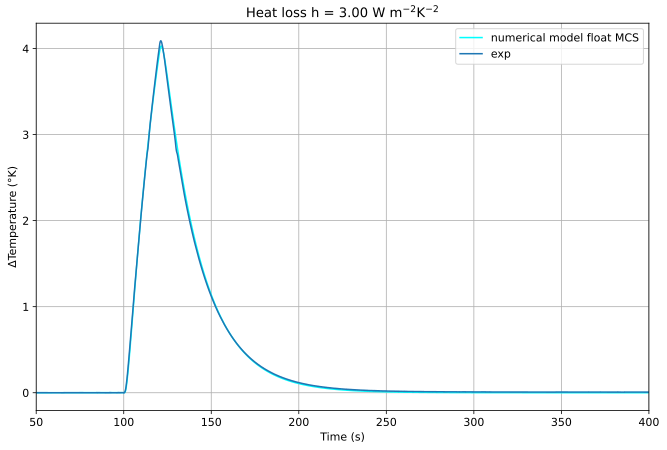

In [144]:
# numerical plot at x=2
d1 =  3.25

T_air = 30 #dgree C

Gain=20

tempData = TS.tempConvert(rawData[:,3],rawData[:,2],att,T_air,T_0,1,Gain,lagTime)
tempData = TS.flatset(tempData,lagTime,dataTime)


ana = TS.anaMet(Q,A,kappa,s,dur,d1,h,a,False,lagTime,dt)
#temp2 = np.zeros(int((dataTime+lagTime)/dt))
#temp2[int(lagTime/dt):] = y[int((atX+d1)/dx),:]
#temp3 = np.zeros(int((dataTime+lagTime)/dt))
#temp3[int(lagTime/dt):] = y1[int((atX+d1)/dx),:]
#temp4 = np.zeros(int((dataTime+lagTime)/dt))
#temp4[int(lagTime/dt):] = y2[int((atX+d1)/dx),:]

plt.figure(figsize=(11, 7))
# plt.figure(figsize=(5, 4))

#Plotting temperatures - MCS
#time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol.t))
#temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol.y[int(N/2-(d1/100)/(dx/100))] ))
#plt.plot(time_mcs,temp_mcs, color = 'red' ,label = 'numerical model sunk MCS')
time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol1.t))##
temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol1.y[int(N/2-(d1/100)/(dx/100))] ))
plt.plot(time_mcs,temp_mcs, color = 'cyan' ,label = 'numerical model float MCS')


# Plotting temperatures - Yash
time_model = np.arange(0,lagTime+dataTime,dt)
#plt.plot(time_model+att*0.5,ana,color="green",label="analytical")
plt.plot(np.arange(0,lagTime+dataTime,0.01),tempData*1,label="exp")
#plt.plot(time_model,temp4,color = 'pink' ,label = 'numerical model3 float')
#plt.plot(time_model,temp3,color = 'black' ,label = 'numerical model2 sunk')
#plt.plot(time_model,temp2,color = 'red' ,label = 'numerical model1 2d radial')

#Plot the float temperatures
#lastones = int(100/dt) #in seconds
#plt.plot(time_model[-lastones:], np.zeros(lastones)+Tend, color="magenta")
#plt.plot(time_model[-lastones:], np.zeros(lastones)+T_float, color="magenta")


plt.legend(loc='upper right')
plt.xlabel("Time (s)")
plt.ylabel("ΔTemperature (°K)")
plt.grid()
plt.xlim(50, 400)
plt.title('Heat loss h = %1.2f W m$^{-2}$K$^{-2}$' %(10000*h) )
#plt.ylim(2.2, 2.7)


(100.0, 200.0)

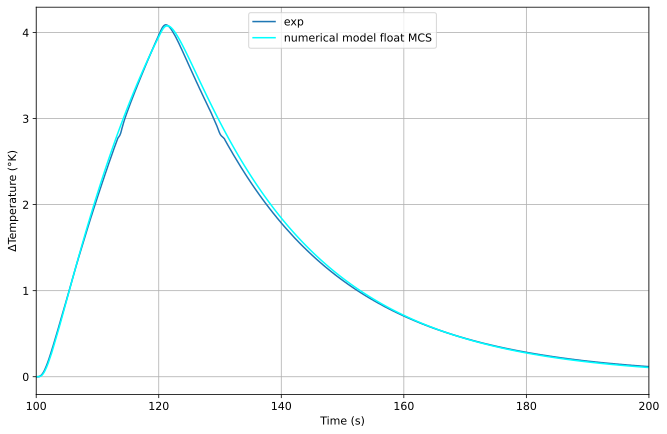

In [149]:
# numerical plot at x=4
d1 =  3.2

tempData = TS.tempConvert(rawData[:,3],rawData[:,2],att,T_air,T_0,1,Gain,lagTime)
tempData = TS.flatset(tempData,lagTime,dataTime)


ana = TS.anaMet(Q,A,kappa,s,dur,d1,h,a,False,lagTime,dt)
#temp2 = np.zeros(int((dataTime+lagTime)/dt))
#temp2[int(lagTime/dt):] = y[int((atX+d1)/dx),:]
#temp3 = np.zeros(int((dataTime+lagTime)/dt))
#temp3[int(lagTime/dt):] = y1[int((atX+d1)/dx),:]
#temp4 = np.zeros(int((dataTime+lagTime)/dt))
#temp4[int(lagTime/dt):] = y2[int((atX+d1)/dx),:]

plt.figure(figsize=(11, 7))
#plt.figure(figsize=(20, 10))
# plt.figure(figsize=(5, 4))

# Plotting temperatures - Yash
time_model = np.arange(0,lagTime+dataTime,dt)
#plt.plot(time_model+att*0.5,ana,color="green",label="analytical")
plt.plot(np.arange(0,lagTime+dataTime,0.01),tempData*1,label="exp")
#plt.plot(time_model,temp4,color = 'pink' ,label = 'numerical model3 float')
#plt.plot(time_model,temp3,color = 'black' ,label = 'numerical model2 sunk')
#plt.plot(time_model,temp2,color = 'red' ,label = 'numerical model1 2d radial')

#Plotting temperatures - MCS
#time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol.t))
#temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol.y[int(N/2-(d1/100)/(dx/100))] ))
#plt.plot(time_mcs,temp_mcs, color = 'red' ,label = 'numerical model sunk MCS')
time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol1.t))
temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol1.y[int(N/2-(d1/100)/(dx/100))] ))
plt.plot(time_mcs,temp_mcs, color = 'cyan' ,label = 'numerical model float MCS')

#Plot the float temperatures
lastones = int(100/dt) #in seconds
plt.plot(time_model[-lastones:], np.zeros(lastones)+Tend, color="magenta")
#plt.plot(time_model[-lastones:], np.zeros(lastones)+T_float, color="magenta")

plt.legend(loc='upper center')
plt.xlabel("Time (s)")
plt.ylabel("ΔTemperature (°K)")
plt.grid()
plt.xlim(100, 200)
#plt.ylim(-.1, .2)


In [146]:
 #( 1 - (4/(G* T_0_ * V_0_)) * (rawData_ -offSet) * (T_air_+273.15) )
V_0 = np.mean(rawData[:,2])
G = TS.gain(resistors,defGain,defGainVal)
print((4/(G* T_0 * V_0)))
print(V_0)
print(2.6/( 1 - (4/(G* T_0 * V_0)) * 2.1 * (T_air+273.15) ))

AttributeError: module 'vMCS_thermoSim' has no attribute 'gain'

In [ ]:
# numerical plot at x=6
d1 =  6.5

tempData = TS.tempConvert(rawData[:,5],rawData[:,2],att,T_air,T_0,1,Gain,lagTime)
tempData = TS.flatset(tempData,lagTime,dataTime)


ana = TS.anaMet(Q,A,kappa,s,dur,d1,h,a,False,lagTime,dt)
#temp2 = np.zeros(int((dataTime+lagTime)/dt))
#temp2[int(lagTime/dt):] = y[int((atX+d1)/dx),:]
#temp3 = np.zeros(int((dataTime+lagTime)/dt))
#temp3[int(lagTime/dt):] = y1[int((atX+d1)/dx),:]
#temp4 = np.zeros(int((dataTime+lagTime)/dt))
#temp4[int(lagTime/dt):] = y2[int((atX+d1)/dx),:]

plt.figure(figsize=(11, 7))
#plt.figure(figsize=(20, 10))
# plt.figure(figsize=(5, 4))

# Plotting temperatures - Yash
#time_model = np.arange(0,lagTime+dataTime,dt)
plt.plot(time_model+att*0.5,ana,color="green",label="analytical")
plt.plot(np.arange(0,lagTime+dataTime,0.01),tempData*1,label="exp")
#plt.plot(time_model,temp4,color = 'pink' ,label = 'numerical model3 float')
#plt.plot(time_model,temp3,color = 'black' ,label = 'numerical model2 sunk')
#plt.plot(time_model,temp2,color = 'red' ,label = 'numerical model1 2d radial')

#Plotting temperatures - MCS
#time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol.t))
#temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol.y[int(N/2-(d1/100)/(dx/100))] ))
#plt.plot(time_mcs,temp_mcs, color = 'red' ,label = 'numerical model sunk MCS')
time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol1.t))
temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol1.y[int(N/2-(d1/100)/(dx/100))] ))
plt.plot(time_mcs,temp_mcs, color = 'cyan' ,label = 'numerical model float MCS')

#Plot the float temperatures
lastones = int(100/dt) #in seconds
plt.plot(time_model[-lastones:], np.zeros(lastones)+Tend, color="magenta")
#plt.plot(time_model[-lastones:], np.zeros(lastones)+T_float, color="magenta")

plt.legend(loc='lower center')
plt.xlabel("Time (s)")
plt.ylabel("ΔTemperature (°K)")
plt.grid()
plt.xlim(98, 600)


In [ ]:
# numerical plot at x=8
d1 =  8.3
# I found that a d1 of 8.6 and multiplying the experimental data by 1.065 with h = .000425 gave good visual agreement, numerical and experiment


tempData = TS.tempConvert(rawData[:,6],rawData[:,2],att,T_air,T_0,1,Gain,lagTime)
tempData = TS.flatset(tempData,lagTime,dataTime)


ana = TS.anaMet(Q,A,kappa,s,dur,d1,h,a,False,lagTime,dt)
#temp2 = np.zeros(int((dataTime+lagTime)/dt))
#temp2[int(lagTime/dt):] = y[int((atX+d1)/dx),:]
#temp3 = np.zeros(int((dataTime+lagTime)/dt))
#temp3[int(lagTime/dt):] = y1[int((atX+d1)/dx),:]
#temp4 = np.zeros(int((dataTime+lagTime)/dt))
#temp4[int(lagTime/dt):] = y2[int((atX+d1)/dx),:]

plt.figure(figsize=(11, 7))
#plt.figure(figsize=(20, 10))
# plt.figure(figsize=(5, 4))

# Plotting temperatures - Yash
time_model = np.arange(0,lagTime+dataTime,dt)
plt.plot(time_model+att*0.5,ana,color="green",label="analytical")
plt.plot(np.arange(0,lagTime+dataTime,0.01),tempData*1,label="exp")
#plt.plot(time_model,temp4,color = 'pink' ,label = 'numerical model3 float')
#plt.plot(time_model,temp3,color = 'black' ,label = 'numerical model2 sunk')
#plt.plot(time_model,temp2,color = 'red' ,label = 'numerical model1 2d radial')

#Plotting temperatures - MCS
#time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol.t))
#temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol.y[int(N/2-(d1/100)/(dx/100))] ))
#plt.plot(time_mcs,temp_mcs, color = 'red' ,label = 'numerical model sunk MCS')
time_mcs = np.concatenate((np.arange(0,lagTime,dt),lagTime+sol1.t))
temp_mcs = np.concatenate((np.zeros(int(lagTime/dt)) , sol1.y[int(N/2-(d1/100)/(dx/100))] ))
plt.plot(time_mcs,temp_mcs, color = 'cyan' ,label = 'numerical model float MCS')

#Plot the float temperatures
lastones = int(100/dt) #in seconds
plt.plot(time_model[-lastones:], np.zeros(lastones)+Tend, color="magenta")
#plt.plot(time_model[-lastones:], np.zeros(lastones)+T_float, color="magenta")

plt.legend(loc='upper center')
plt.xlabel("Time (s)")
plt.ylabel("ΔTemperature (°K)")
plt.grid()
plt.xlim(100, 200)
